In [1]:
import sys
from tqdm import tqdm

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.processor import Processor
from main import init_parser, update_parameters

In [2]:
parser = init_parser()
evaluation_case = 'CV'
# (T2: 12 Apr) Model
sys.argv = ['notebook_cell', '--config', './config/ntu_ablation/ntu60_angle-view.yaml', '-e', '--alignment', 'unaligned']
args = parser.parse_args()
args = update_parameters(parser, args)  # cmd > yaml > default

p = Processor(args)
p.start()

[ 2026-04-30 14:21:42,605 ] Saving folder path: ./workdir/ntu_angle/temp
[ 2026-04-30 14:21:42,606 ] 
[ 2026-04-30 14:21:42,610 ] Saving model name: Trans-GCN_ntu60
[ 2026-04-30 14:21:43,299 ] Using unaligned data.
[ 2026-04-30 14:22:06,426 ] Dataset: ntu60
[ 2026-04-30 14:22:06,427 ] Batch size: train-64, eval-128
[ 2026-04-30 14:22:06,428 ] Data shape (branch, channel, frame, joint, person): [1, 3, 64, 25, 2]
[ 2026-04-30 14:22:06,428 ] Number of action classes: 60
[ 2026-04-30 14:22:06,473 ] Model: Trans-GCN {'use_att': True, 'kernel_size': [3, 2], 'dilations': [2, 3], 'reduct_ratio': 2, 'use_gcn': False, 'so2_arg': {'heads': 8, 'angle_partitions': 6, 'rot_one_axis': False}}
[ 2026-04-30 14:22:07,705 ] Model profile: 0.57G FLOPs and 0.74M Parameters
[ 2026-04-30 14:22:08,570 ] Optimizer: SGD {'lr': 0.1, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.0002}
[ 2026-04-30 14:22:08,571 ] LR_Scheduler: step {'max_epoch': 100, 'warm_up': 0, 'step_lr': [80, 90]}
[ 2026-04-30 14:22:08,

100%|██████████| 148/148 [00:50<00:00,  2.91it/s]

[ 2026-04-30 14:22:59,446 ] Top-1 accuracy: 12893/18932(68.10%), MPCA: 68.11%, Top-5 accuracy: 17212/18932(90.91%), Mean loss:1.3208
[ 2026-04-30 14:22:59,447 ] Evaluating time: 50.80s, Speed: 372.90 sequnces/(second*GPU)
[ 2026-04-30 14:22:59,448 ] 
[ 2026-04-30 14:22:59,453 ] Finish evaluating!


In [3]:
def ntu60_label_to_name(label: int) -> str:
    """
    Returns the NTU RGB+D 60 action name for a given label (0-59).

    Args:
        label (int): Action label in [0, 59]

    Returns:
        str: Action class name
    """
    ntu60_classes = [
        "drink water", #0
        "eat meal/snack", #1
        "brushing teeth", #2
        "brushing hair", #3
        "drop", #4
        "pickup", #5
        "throw", #6
        "sitting down", #7
        "standing up (from sitting position)", #8
        "clapping", #9
        "reading", #10
        "writing", #11
        "tear up paper", #12
        "wear jacket", #13
        "take off jacket", #14
        "wear a shoe", #15
        "take off a shoe", #16
        "wear on glasses", #17
        "take off glasses", #18
        "put on a hat/cap", #19
        "take off a hat/cap", #20
        "cheer up", #21
        "hand waving", #22
        "kicking something", #23
        "reach into pocket", #24
        "hopping (one foot jumping)", #25
        "jump up", #26
        "make a phone call/answer phone", #27
        "playing with phone/tablet", #28
        "typing on a keyboard", #29
        "pointing to something with finger", #30
        "taking a selfie", #31
        "check time (from watch)", #32
        "rub two hands together", #33
        "nod head/bow", #34
        "shake head", #35
        "wipe face", #36
        "salute", #37
        "put palms together", #38
        "cross hands in front (say stop)", #39
        "sneeze/cough", #40
        "staggering", #41
        "falling", #42
        "touch head (headache)", #43
        "touch chest (stomachache/heart pain)", #44
        "touch back (backache)", #45
        "touch neck (neckache)", #46
        "nausea or vomiting condition", #47
        "use a fan (with hand or paper)/feeling warm", #48
        "punching/slapping other person", #49
        "kicking other person", #50
        "pushing other person", #51
        "pat on back of other person", #52
        "point finger at the other person", #53
        "hugging other person", #54
        "giving something to other person", #55
        "touch other person's pocket", #56
        "handshaking", #57
        "walking towards each other", #58
        "walking apart from each other" #59
    ]

    if not (0 <= label < 60):
        raise ValueError("Label must be in the range [0, 59].")

    return ntu60_classes[label]


In [4]:
def get_correct_samples(p, class_idx, count=1, split='train', device='cuda', debug=False):
    """
    Returns N correctly classified samples of a given class.
    
    Output:
        xs: list of tensors
        ys: list of labels
    """
    model = p.model

    model.eval()
    xs, ys = ([], []) if not debug else (set(),set())

    loader = p.train_loader if split == 'train' else p.eval_loader

    with torch.no_grad():
        for x_batch, y_batch in tqdm(loader, dynamic_ncols=True):

            x_batch = x_batch.float().to(device)
            y_batch = y_batch.to(device)

            # forward pass
            outputs,_ = model(x_batch)
            preds = outputs.argmax(dim=1)

            # loop through batch
            for i in range(len(y_batch)):
                y_true = y_batch[i].item()
                y_pred = preds[i].item()

                if not debug:
                    if y_true == class_idx and y_pred == class_idx:
                        xs.append(x_batch[i].cpu())
                        ys.append(y_true)

                        if len(xs) == count:
                            return xs, ys
                else:
                    if y_true == y_pred:
                        ys.add(y_true)
                    

    return (xs, ys) if not debug else ys  # may be < count if not enough found

In [5]:
def make_z1f_hook(axis='y', storage_dict=None, layer=None, head=None):
    def hook(module, input, output):
        x = input[0]

        NM, T, V, C = x.shape

        sigma = module.sigma_k[axis](
            x.reshape(NM, T, -1).unsqueeze(2)
        ).squeeze(-2)  # (NM, T, n)

        z1_f = torch.sigmoid(sigma)

        storage_dict[(layer, head)] = z1_f.detach().cpu()

    return hook

In [6]:
def register_all_hooks(model, storage, axis='y'):
    net = model.module if isinstance(model, torch.nn.DataParallel) else model

    handles = []

    for l, layer in enumerate(net.main_stream):
        for h, gcn in enumerate(layer.scn.gcn):
            handle = gcn.register_forward_hook(
                make_z1f_hook(axis=axis, storage_dict=storage, layer=l, head=h)
            )
            handles.append(handle)

    return handles

In [7]:
def build_z1f_matrix_proportional(storage, sample_idx=0, actor=0, k=16):
    """
    storage: dict[(layer, head)] → (NM, T, n)

    Returns:
        matrix: (k * L * H, n)
    """

    keys = sorted(storage.keys())  # (layer, head)

    # group keys by layer
    layer_dict = {}
    for (l, h) in keys:
        layer_dict.setdefault(l, []).append(h)

    rows = []

    for t_step in range(k):  # normalized time steps
        t_norm = t_step / (k - 1)

        for l in sorted(layer_dict.keys()):
            for h in sorted(layer_dict[l]):

                z = storage[(l, h)]  # (NM, T, n)
                NM, T, n = z.shape
                z = z.view(-1,2,T,n)

                # map normalized time → actual index
                t_idx = int(round(t_norm * (T - 1)))

                row = z[sample_idx, actor, t_idx]  # (n,)
                rows.append(row)

    matrix = torch.stack(rows)  # (k * L * H, n)

    return matrix.numpy()

In [8]:
def plot_z1f_global(matrix):
    plt.figure(figsize=(8, 6))
    plt.imshow(matrix, aspect='auto')

    plt.title("z1_f (Proportional Time Sampling)")
    plt.xlabel("Partition index (n)")
    plt.ylabel("Time (normalized) × Layer × Head")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [9]:
class_idx = 7 # 7: sitting, 8: standing
count = 4
split = 'test'

x, y = get_correct_samples(p, class_idx, count=count, split=split)

class_name = ntu60_label_to_name(class_idx) # class name

print(f"class name is {class_name}.")

  1%|          | 1/148 [00:00<01:28,  1.66it/s]

class name is sitting down.


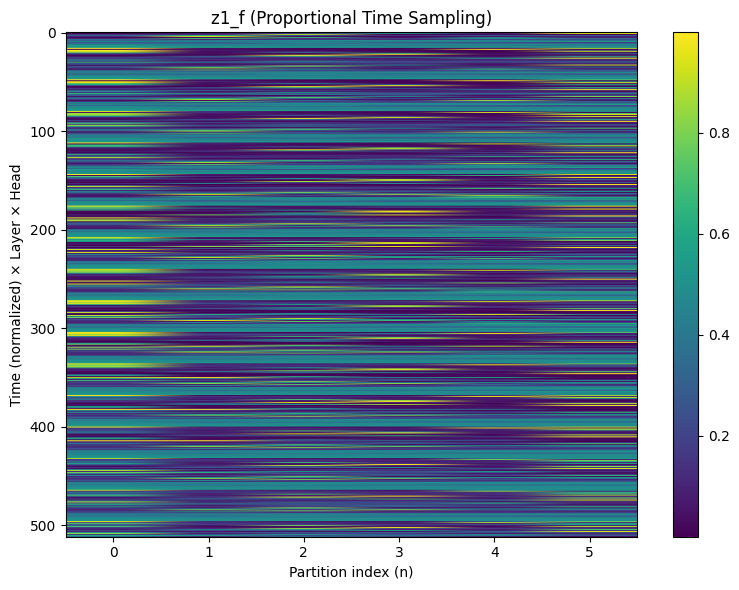

In [10]:
x_sample = x[3].unsqueeze(0)

model = p.model

storage = {}

handles = register_all_hooks(model, storage, axis='x')

model.eval()
with torch.no_grad():
    _ = model(x_sample)

# remove hooks
for h in handles:
    h.remove()

# build matrix
matrix = build_z1f_matrix_proportional(
    storage,
    sample_idx=0,
    actor=0,
    k=16
)

# plot x-axis
plot_z1f_global(matrix)

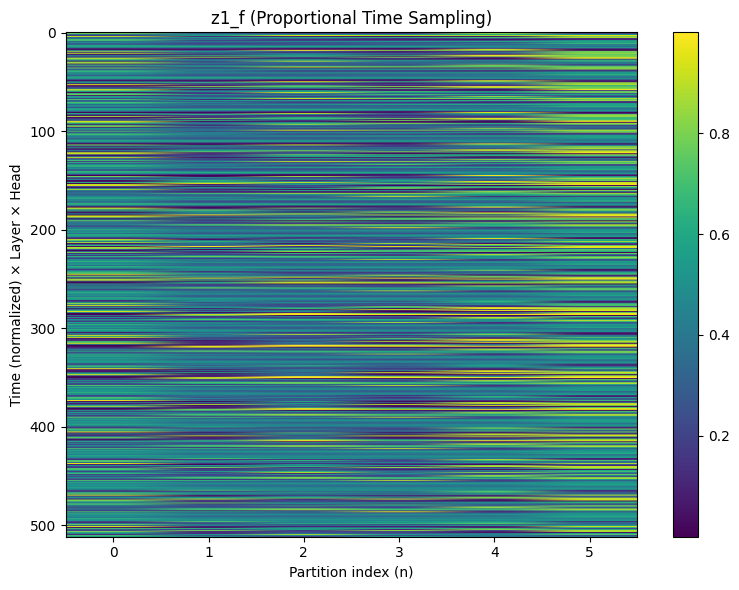

In [11]:
x_sample = x[3].unsqueeze(0)

model = p.model

storage = {}

handles = register_all_hooks(model, storage, axis='y')

model.eval()
with torch.no_grad():
    _ = model(x_sample)

# remove hooks
for h in handles:
    h.remove()

# build matrix
matrix = build_z1f_matrix_proportional(
    storage,
    sample_idx=0,
    actor=0,
    k=16
)

# plot y-axis
plot_z1f_global(matrix)

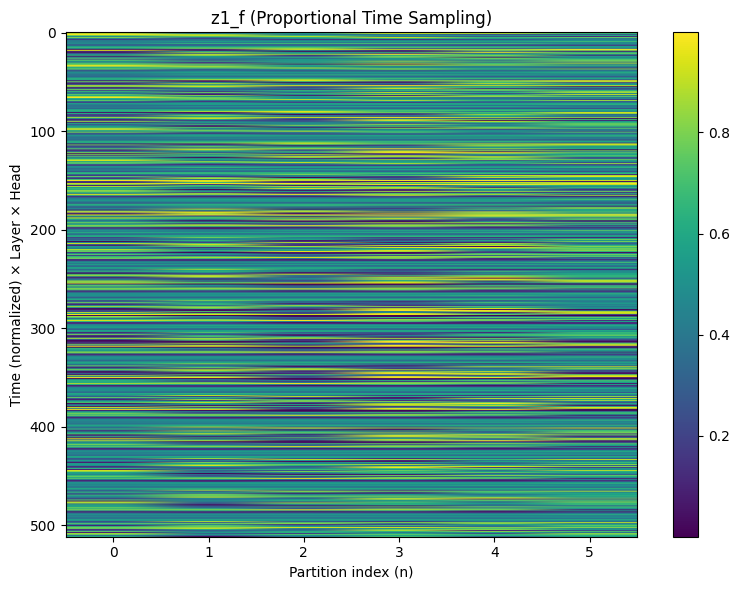

In [12]:
x_sample = x[3].unsqueeze(0)

model = p.model

storage = {}

handles = register_all_hooks(model, storage, axis='z')

model.eval()
with torch.no_grad():
    _ = model(x_sample)

# remove hooks
for h in handles:
    h.remove()

# build matrix
matrix = build_z1f_matrix_proportional(
    storage,
    sample_idx=0,
    actor=0,
    k=16
)

# plot z-axis
plot_z1f_global(matrix)

In [38]:
def plot_all_axes_z1f(
    model,
    x_sample,
    k=16,
    actor=0,
    sample_idx=0,
    axes=('x', 'y', 'z'),
    class_name=None,
    save=False
):
    """
    Generates heatmaps for x, y, z axes in one figure.

    Args:
        model: trained model
        x_sample: (1, C, T, V, M) input sample
        k: number of proportional time samples
        sample_idx: index in batch (usually 0)
        axes: tuple of axes to plot
    """

    net = model.module if isinstance(model, torch.nn.DataParallel) else model
    net.eval()

    device = next(net.parameters()).device
    x_sample = x_sample.to(device)

    fig, axs = plt.subplots(1, len(axes), figsize=(5 * len(axes), 5))

    if len(axes) == 1:
        axs = [axs]

    for i, axis in enumerate(axes):

        # storage per axis
        storage = {}

        # register hooks
        handles = register_all_hooks(net, storage, axis=axis)

        # forward pass
        with torch.no_grad():
            _ = net(x_sample)

        # remove hooks
        for h in handles:
            h.remove()

        # build matrix (proportional time)
        matrix = build_z1f_matrix_proportional(
            storage,
            sample_idx=sample_idx,
            actor=actor,
            k=k
        )

        # plot
        im = axs[i].imshow(matrix, aspect='auto')

        axs[i].set_title(f"Axis: {axis}")
        axs[i].set_xlabel("Angle Partition")
        axs[i].set_ylabel("Time × Layer × Head")

        fig.colorbar(im, ax=axs[i])

    plt.tight_layout()
    if save:
        # Clean the class name
        class_name = class_name.replace('/', '_or_')
        
        # Create the optional actor suffix
        actor_suffix = f"_actor{actor}" if actor != 0 else ""
        
        # Save using a single formatted string
        plt.savefig(f"zz_ablatn_images/sigma_{class_name}{actor_suffix}.png", dpi=300)
    plt.show()

  2%|▏         | 3/148 [00:01<00:58,  2.48it/s]


class name is hugging other person.


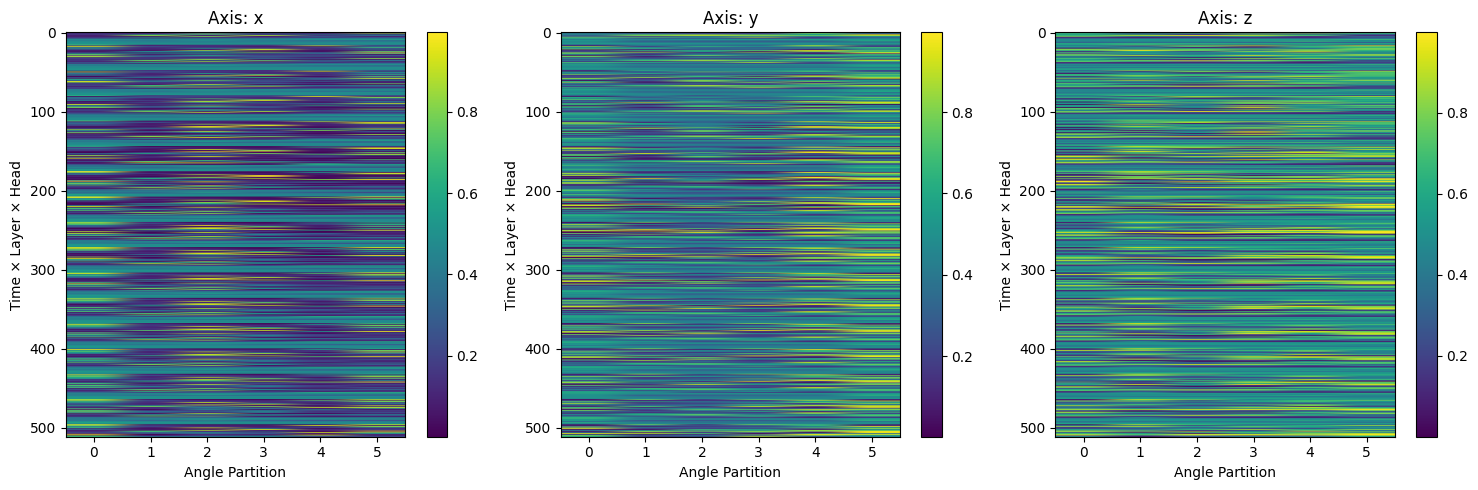

In [42]:
class_idx = 54 # 6: throw, 7: sitting, 8: standing, 54: hugging other person
count = 4
split = 'test'
sample = 0

x, y = get_correct_samples(p, class_idx, count=count, split=split)

class_name = ntu60_label_to_name(class_idx) # class name

print(f"class name is {class_name}.")

x_sample = x[sample].unsqueeze(0)

plot_all_axes_z1f(
    model=p.model,
    x_sample=x_sample,
    k=16,
    actor=1,
    class_name=class_name,
    save=True
)

# Points to Write
- Since the heatmap shows the z-axis higher, it means the model is able to identify the right orientation needed by a sample.
- You should also provide 2 samples of the same class.
- And 2 separate classes.